<a href="https://colab.research.google.com/github/dominicwooldridge/GSB-S544/blob/Practice-Activities/Practice_Activity_6.2_Multiple_Linear_Regression_and_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Palmer Penguins Modeling

Import the Palmer Penguins dataset and print out the first few rows.

Suppose we want to predict `bill_depth_mm` using the other variables in the dataset.

**Dummify** all variables that require this.

In [1]:
# Code Here
!pip install palmerpenguins
from palmerpenguins import load_penguins
penguins = load_penguins()
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [3]:
import numpy as np
import pandas as pd
penguins = pd.get_dummies(penguins, columns=['species', 'island', 'sex'])
penguins.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen,sex_female,sex_male
0,39.1,18.7,181.0,3750.0,2007,True,False,False,False,False,True,False,True
1,39.5,17.4,186.0,3800.0,2007,True,False,False,False,False,True,True,False
2,40.3,18.0,195.0,3250.0,2007,True,False,False,False,False,True,True,False
3,NaN,NaN,NaN,NaN,2007,True,False,False,False,False,True,False,False
4,36.7,19.3,193.0,3450.0,2007,True,False,False,False,False,True,True,False


Let's use the other variables to predict `bill_depth_mm`. Prepare your data and fit the following models on a training dataset subset of the entire dataset:

* Four different models, each containing a different set of predictor variables

Create a plot like the right plot of Fig 1. in our `Model Validation` chapter with the training and test error plotted for each of your four models.

Which of your models was best?

In [4]:
# Code Here

import pandas as pd
from sklearn.model_selection import train_test_split

peng = penguins.dropna(subset=['bill_depth_mm', 'bill_length_mm', 'flipper_length_mm', 'body_mass_g'])


y = peng['bill_depth_mm']
train, test = train_test_split(peng, test_size=0.3, random_state=42)


In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

cols_needed = ['bill_depth_mm','bill_length_mm','flipper_length_mm','body_mass_g','year']
peng = penguins.dropna(subset=cols_needed)

y = peng['bill_depth_mm']
train, test = train_test_split(peng, test_size=0.30, random_state=42)

def RMSE(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

models = {
    "Model 1": ['bill_length_mm'],
    "Model 2": ['bill_length_mm', 'flipper_length_mm'],
    "Model 3": ['bill_length_mm', 'flipper_length_mm', 'body_mass_g'],
    "Model 4": ['bill_length_mm', 'flipper_length_mm', 'body_mass_g', 'year'],
}

rows = []
for name, Xcols in models.items():
    m = LinearRegression().fit(train[Xcols], train[y.name])
    tr_rmse = RMSE(train[y.name], m.predict(train[Xcols]))
    te_rmse = RMSE(test[y.name],  m.predict(test[Xcols]))
    rows.append({"Model": name, "Train RMSE": tr_rmse, "Test RMSE": te_rmse})

err = pd.DataFrame(rows)
print(err)


     Model  Train RMSE  Test RMSE
0  Model 1    1.876994   2.007148
1  Model 2    1.532058   1.606068
2  Model 3    1.531340   1.598254
3  Model 4    1.530384   1.586837


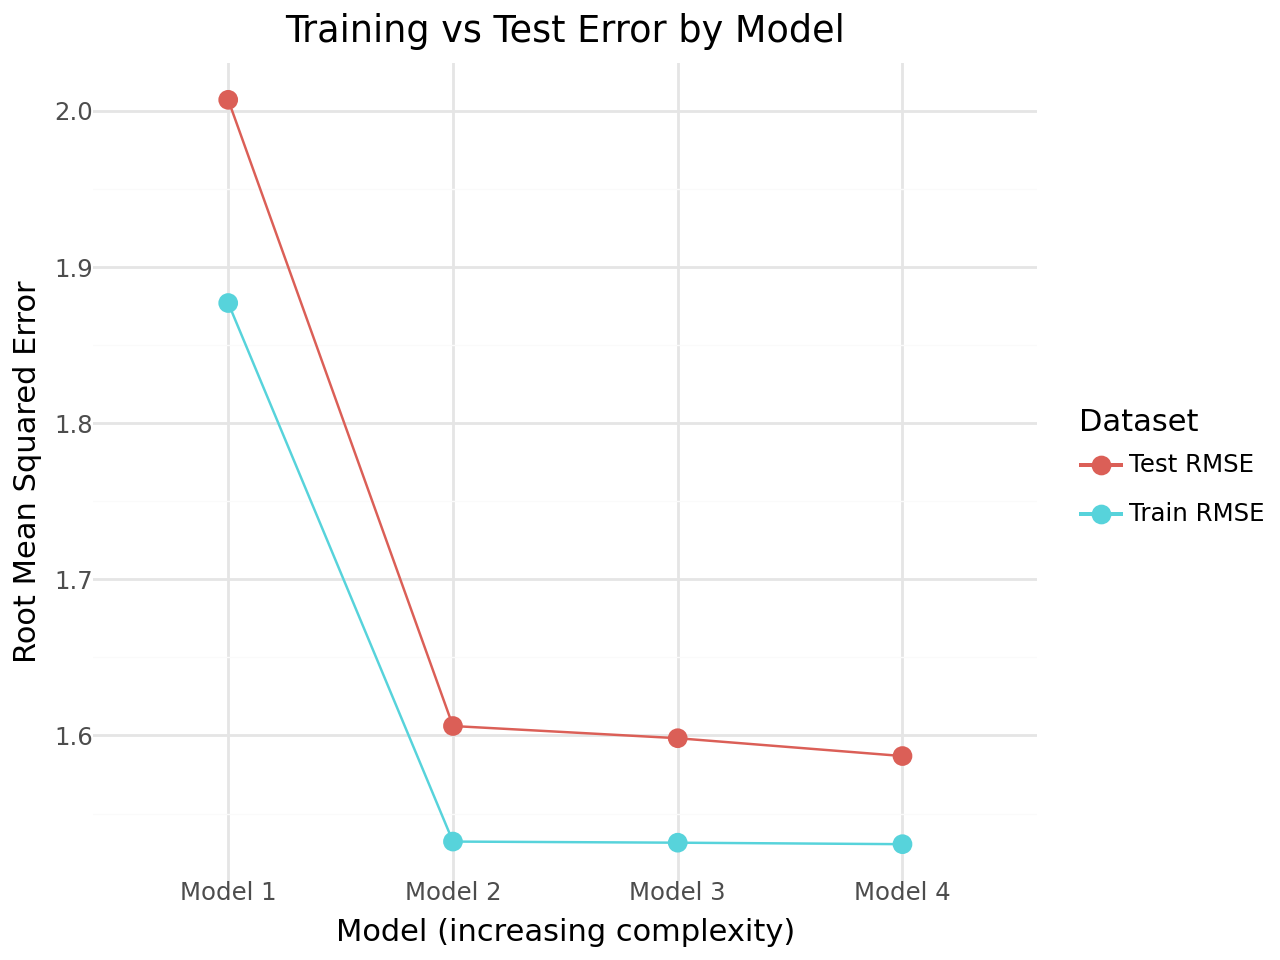

In [7]:
from plotnine import ggplot, aes, geom_point, geom_line, labs, theme_minimal

err_long = err.melt(id_vars='Model', var_name='Dataset', value_name='RMSE')

(
    ggplot(err_long, aes(x='Model', y='RMSE', color='Dataset', group='Dataset'))
    + geom_point(size=3)
    + geom_line()
    + labs(title='Training vs Test Error by Model',
           x='Model (increasing complexity)',
           y='Root Mean Squared Error')
    + theme_minimal()
)
